<a href="https://colab.research.google.com/github/KeithRajbhandari/KRB-HTML/blob/main/Week_4_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload 'WA_Fn-UseC_-Telco-Customer-Churn.csv':


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (3).csv

1. LOGISTIC REGRESSION MODEL


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.7875

Classification Report:
               precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



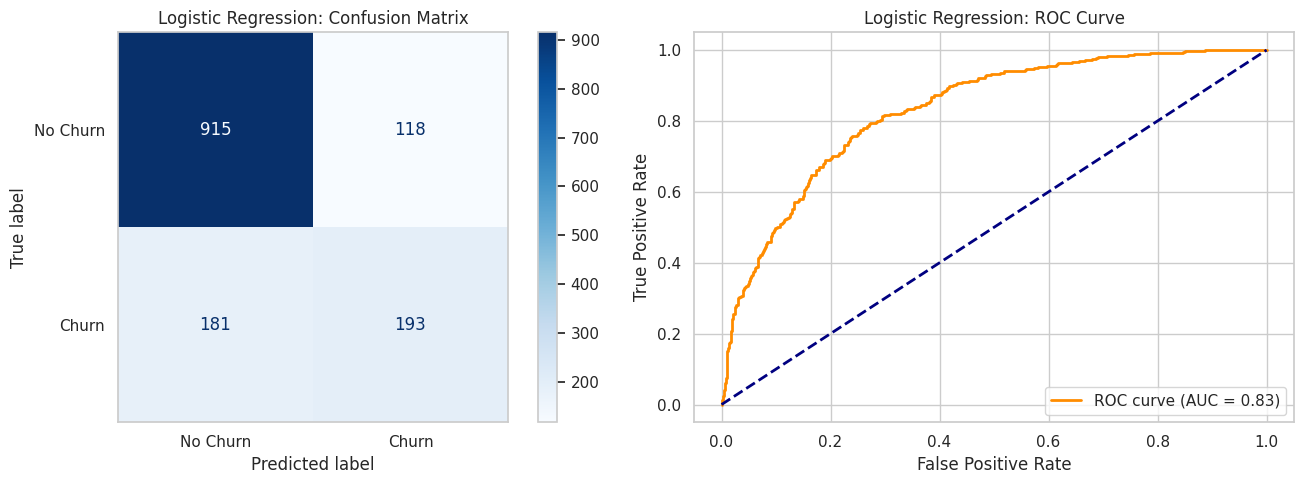


2. BASELINE DECISION TREE (Depth = 4)
Baseline Tree Accuracy: 0.7846

Classification Report:
               precision    recall  f1-score   support

       False       0.84      0.88      0.86      1033
        True       0.61      0.53      0.57       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.78      0.78      0.78      1407



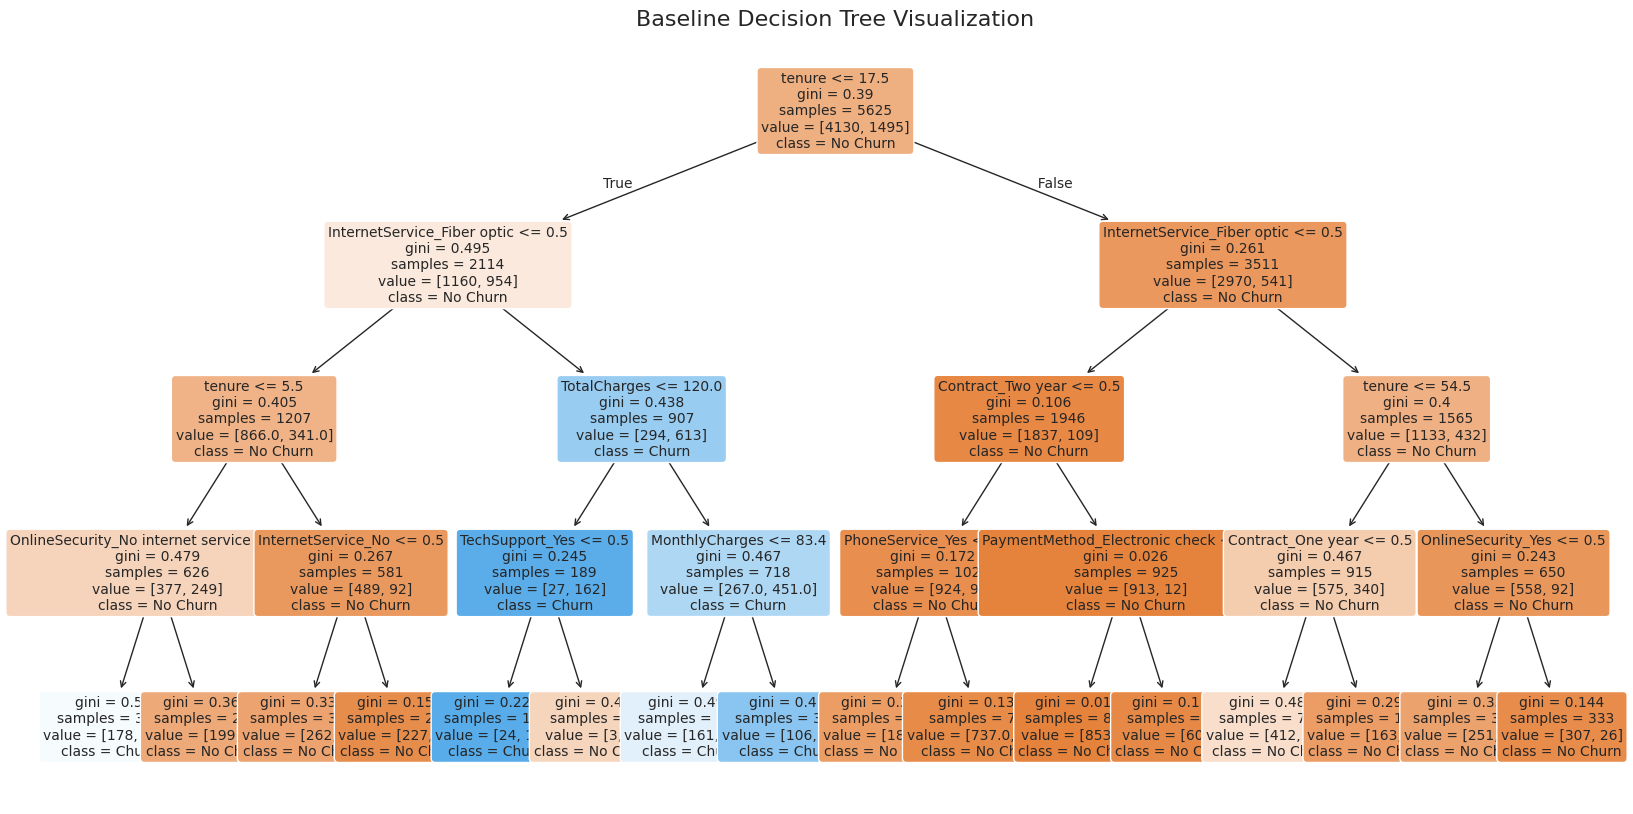


3. TUNED DECISION TREE (HYPERPARAMETER OPTIMIZATION)
Best Parameters Found by GridSearchCV:
  - criterion: entropy
  - max_depth: 6
  - min_samples_leaf: 10
  - min_samples_split: 2

Tuned Tree Test Accuracy: 0.7711

Classification Report:
               precision    recall  f1-score   support

       False       0.85      0.83      0.84      1033
        True       0.57      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407



/tmp/ipykernel_1029/3614262577.py:162: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, ax=axes[1], palette='viridis')


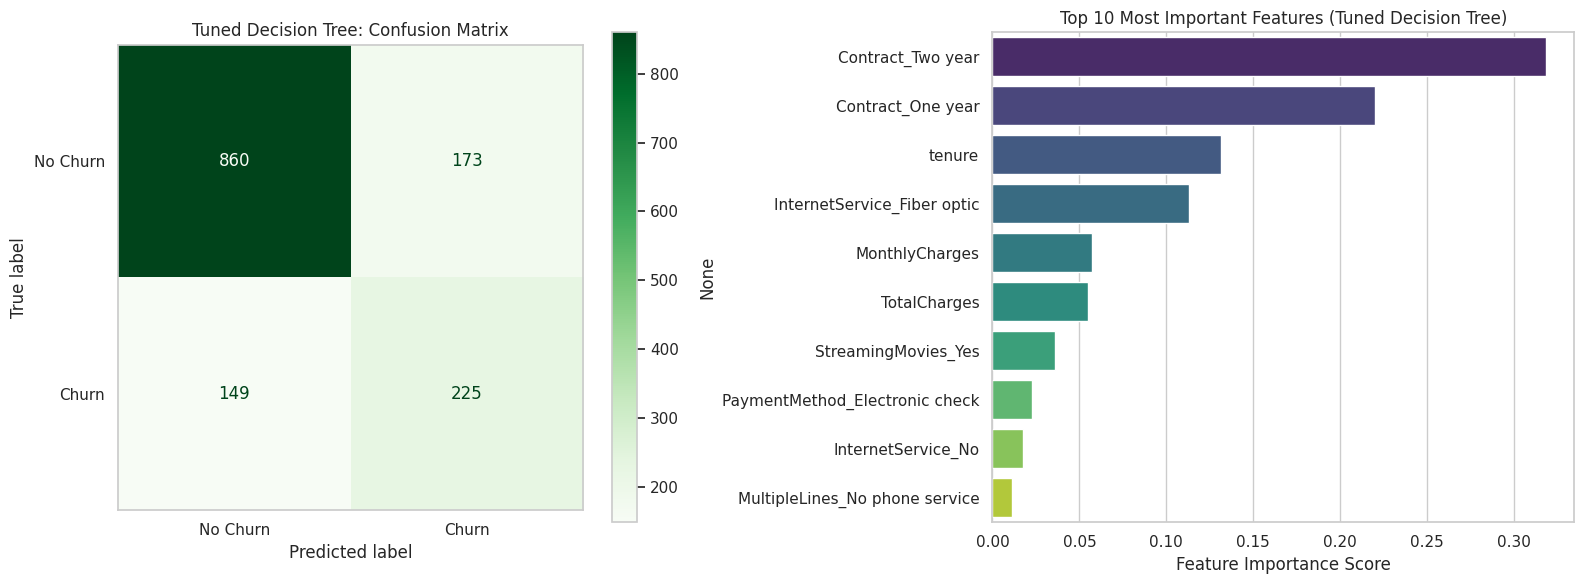

In [4]:
# 1. Setup & Dependencies
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

# 2. Upload and Load Data
print("Please upload 'WA_Fn-UseC_-Telco-Customer-Churn.csv':")
uploaded = files.upload()

file_name = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_name)

# 3. Data Cleaning & Encoding
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Drop identifier column
df_ml = df.drop(columns=['customerID'])

# One-hot encode categorical variables
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Define X (features) and y (target)
X = df_ml.drop(columns=['Churn_Yes'])
y = df_ml['Churn_Yes']

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# ==========================================
# MODEL 1: LOGISTIC REGRESSION & VISUALS
# ==========================================
print("\n" + "="*50)
print("1. LOGISTIC REGRESSION MODEL")
print("="*50)

log_model = LogisticRegression(max_iter=2000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))

# Visual 1.1: Logistic Regression Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Churn', 'Churn'])
disp_log.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression: Confusion Matrix')
axes[0].grid(False)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_log)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression: ROC Curve')
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


# ==========================================
# MODEL 2: BASELINE DECISION TREE & VISUALS
# ==========================================
print("\n" + "="*50)
print("2. BASELINE DECISION TREE (Depth = 4)")
print("="*50)

tree_base = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_base.fit(X_train, y_train)

y_pred_tree_base = tree_base.predict(X_test)

print(f"Baseline Tree Accuracy: {accuracy_score(y_test, y_pred_tree_base):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree_base))

# Visual 2.1: Tree Structure Diagram
plt.figure(figsize=(20, 10))
plot_tree(
    tree_base,
    feature_names=X.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Baseline Decision Tree Visualization', fontsize=16)
plt.show()


# ==========================================
# MODEL 3: TUNED DECISION TREE (GridSearchCV)
# ==========================================
print("\n" + "="*50)
print("3. TUNED DECISION TREE (HYPERPARAMETER OPTIMIZATION)")
print("="*50)

# Define Hyperparameter Search Space
param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Hyperparameter Tuning using 5-Fold Cross-Validation
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_tree = grid_search.best_estimator_

y_pred_tree_tuned = best_tree.predict(X_test)

print("Best Parameters Found by GridSearchCV:")
for param, val in grid_search.best_params_.items():
    print(f"  - {param}: {val}")

print(f"\nTuned Tree Test Accuracy: {accuracy_score(y_test, y_pred_tree_tuned):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree_tuned))

# Visual 3.1: Confusion Matrix Comparison & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tuned Tree Confusion Matrix
cm_tuned = confusion_matrix(y_test, y_pred_tree_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Churn', 'Churn'])
disp_tuned.plot(ax=axes[0], cmap='Greens', values_format='d')
axes[0].set_title('Tuned Decision Tree: Confusion Matrix')
axes[0].grid(False)

# Feature Importance Plot
importances = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Most Important Features (Tuned Decision Tree)')
axes[1].set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.show()